In [1]:
import numpy as np
import matplotlib.pyplot as plt
#import matplotlib, sys
#print(hasattr(matplotlib, "get_data_path"))

# Parameters

In [2]:

T=1         # ending time
m=200       # step size
gamma=1/10  # risk aversion, i.e. overweighting of losses
dt=T/m      #time steps

S0=100      #initial stock value
sigma=5     # volatility


#intensity parameters for
k=3/2       # intesnsity parameter 1
A=140       # intesnsity parameter 2


m0=1000     #initial cash



In [3]:

# relative change of the Stock
def dSt(dt,T,sigma):
    m = int(T/dt)
    return np.random.normal(0,sigma/np.sqrt(m),200)


#We need a joint measure for simulating different Poisson processes

def lambda_intensity(A,k,delta):
    return A*np.exp(-k*delta)





def agent_constant_spread(S,d1,d2,x0, q0=0):
    bids_filled = np.random.poisson(lam=lambda_intensity(A,k,d1)/200, size=200)
    asks_filled = np.random.poisson(lam=lambda_intensity(A,k,d2)/200, size=200)
    dq = bids_filled-asks_filled
    revenue_bids = -bids_filled*(S-d1)
    revenue_asks = asks_filled*(S+d2)
    cash_change = revenue_bids+revenue_asks
    q_stocks = q0 + np.cumsum(dq)
    money = x0 + np.cumsum(cash_change)
    TotalValue = money + q_stocks * S
    return {
        'q_stocks':q_stocks,
        'money': money,
        'TotalValue': TotalValue
    }


def agent_AS_model(S,x0,q0=0):
    r=gamma*sigma**2 *(T-np.arange(200) / 200)+2*np.log(1+gamma/k)/gamma
    d1=r/2
    d2=r/2
    bids_filled = np.random.poisson(lam=lambda_intensity(A,k,d1)/200, size=200)
    asks_filled = np.random.poisson(lam=lambda_intensity(A,k,d2)/200, size=200)
    dq = bids_filled-asks_filled
    revenue_bids = -bids_filled*(S-d1)
    revenue_asks = asks_filled*(S+d2)
    cash_change = revenue_bids+revenue_asks
    q_stocks = q0 + np.cumsum(dq)
    money = x0 + np.cumsum(cash_change)
    TotalValue = money + q_stocks * S
    return {
        'q_stocks':q_stocks,
        'money': money,
        'TotalValue': TotalValue
    }




def v(gamma,x,s,q,t,T,sigma):
    return - np.exp(-gamma* x)*np.exp(-gamma*q*s)*np.exp(gamma**2*q**2*sigma**2*(T-t)/2)


Stocks=[dSt(dt,T,sigma)for i in range(1000)]



In [4]:

n=len(Stocks)
revenue_const=[]
revenue_AS=[]
value_const=[]
value_AS=[]

for s in Stocks:
    result =agent_constant_spread(s,1,1,1000)
    result2 =agent_AS_model(s,1000)
    revenue_const+=[result['TotalValue'][-1]]
    revenue_AS+=[result2['TotalValue'][-1]]
    value_const+=[-np.exp(-gamma*(result['TotalValue'][-1]-1000)/1)]
    value_AS+=[-np.exp(-gamma*(result2['TotalValue'][-1]-1000)/1)]

print('mean: ',np.mean(revenue_const),
'median: ',np.median(revenue_const),
'std: ',np.std(revenue_const),       # standard deviation
'min: ',np.min(revenue_const),       # minimum
'max: ',np.max(revenue_const)
)
print('mean: ',np.mean(revenue_AS),
'median: ',np.median(revenue_AS),
'std: ',np.std(revenue_AS),       # standard deviation
'min: ',np.min(revenue_AS),       # minimum
'max: ',np.max(revenue_AS)
)



print('mean: ',np.mean(value_const),
'median: ',np.median(value_const),
'std: ',np.std(value_const),       # standard deviation
'min: ',np.min(value_const),       # minimum
'max: ',np.max(value_const)
)
print('mean: ',np.mean(value_AS),
'median: ',np.median(value_AS),
'std: ',np.std(value_AS),       # standard deviation
'min: ',np.min(value_AS),       # minimum
'max: ',np.max(value_AS)
)





mean:  1062.859506441621 median:  1062.547496980703 std:  8.786585452415556 min:  1037.3167862089401 max:  1092.8009446545473
mean:  1052.1777118715718 median:  1051.8470775139742 std:  8.722259551640247 min:  1025.9151330873642 max:  1085.250991341575
mean:  -0.00271018657033381 median:  -0.001921306818881614 std:  0.002726144966493997 min:  -0.023952594745384567 max:  -9.32623129820074e-05
mean:  -0.007786386657834889 median:  -0.005601575564607494 std:  0.007494402076132457 min:  -0.07490659746176544 max:  -0.0001984250454055662


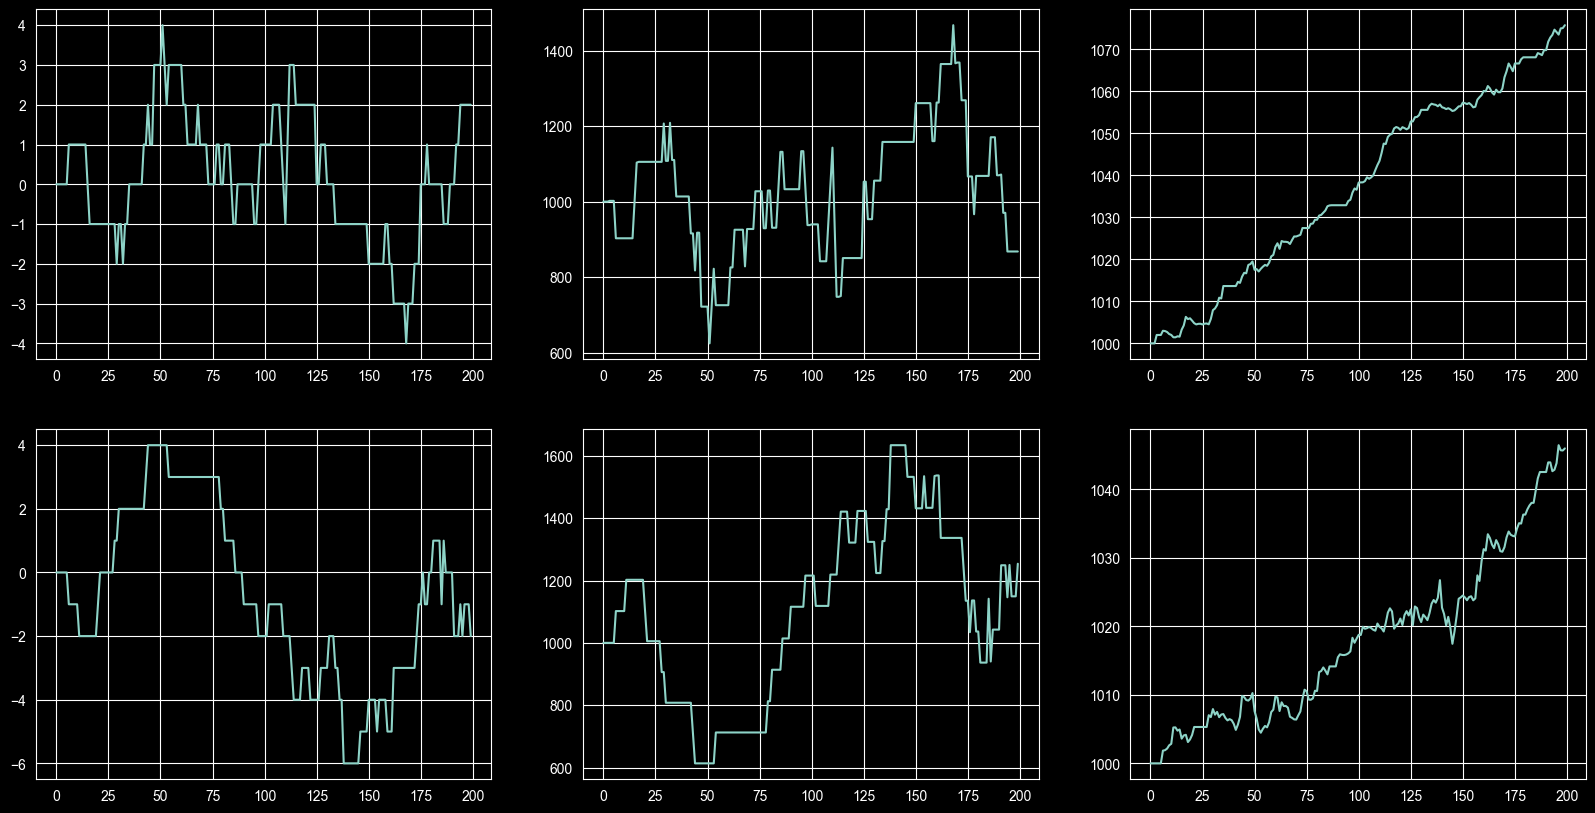

In [5]:
S=100+np.cumsum(Stocks[0])

result =agent_constant_spread(S,1,1,1000)
fig, axis = plt.subplots(2,3,figsize=(20,10))
axis[0,0].plot(result['q_stocks'])
axis[0,1].plot(result['money'])
axis[0,2].plot(result['TotalValue'])

result2 =agent_AS_model(S,1000)
axis[1,0].plot(result2['q_stocks'])
axis[1,1].plot(result2['money'])
axis[1,2].plot(result2['TotalValue'])

plt.show()




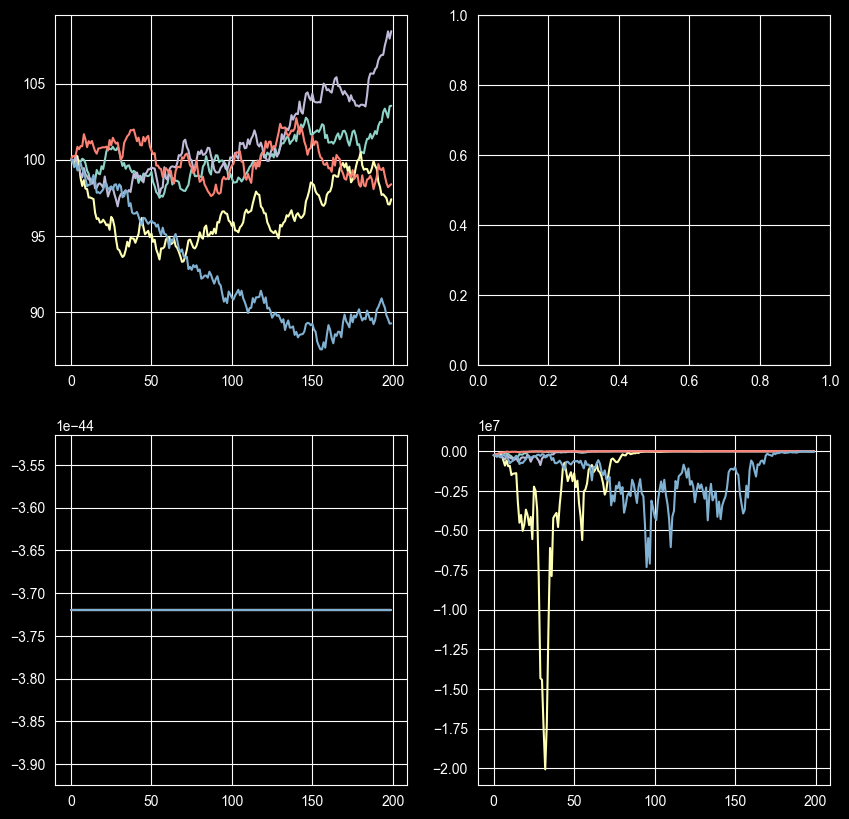

In [6]:

fig, axis = plt.subplots(2,2,figsize=(10,10))
for i in range(5):
    s=Stocks[i]
    S=[S0+sum(s[:i]) for i in range(200)]
    V1=[v(gamma,m0,sum(Stocks[i][:j]),0,(j+1)/200,T,sigma)  for j in range(200)]
    V2=[v(gamma,0,sum(Stocks[i][:j]),m0/S0,(j+1)/200,T,sigma)  for j in range(200)]
    axis[0,0].plot(S)
    axis[1,0].plot(V1)
    axis[1,1].plot(V2)

plt.show()


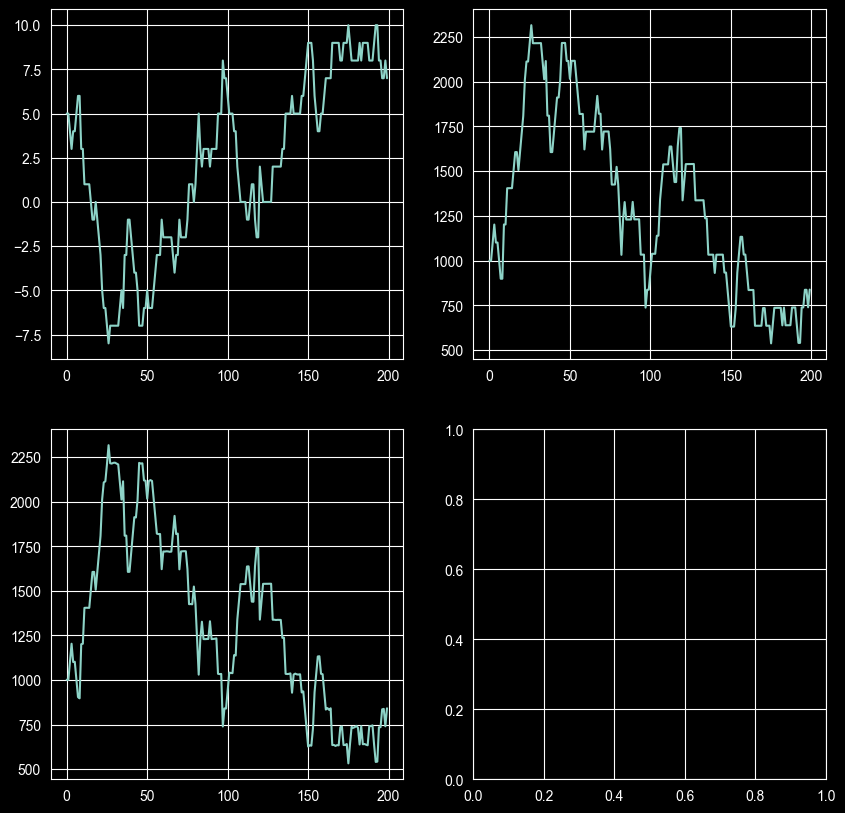

In [7]:

d1=0.2
d2=0.2

fig, axis = plt.subplots(2,2,figsize=(10,10))
for i in range(3,4):
    s=Stocks[i]
    S=100+np.cumsum(s)#[100+sum(s[:i]) for i in range(200)]
    bids_filled = np.random.poisson(lam=lambda_intensity(A,k,d1)/200, size=200)
    asks_filled = np.random.poisson(lam=lambda_intensity(A,k,d2)/200, size=200)
    q0=5
    x0=1000

    dq = bids_filled-asks_filled
    revenue_bids = -bids_filled*(S-d1)
    revenue_asks = asks_filled*(S+d2)
    cash_change = revenue_bids+revenue_asks
    q_stocks = q0 + np.cumsum(dq)
    money = x0 + np.cumsum(cash_change)

    TotalValue = money + q_stocks * s

    axis[0,0].plot(q_stocks)
    axis[0,1].plot(money)
    axis[1,0].plot(TotalValue)

plt.show()


In [166]:
nexp=0
npoiss=0
N=10**3
n=10**3
for i in range(N):
    rexp=np.random.exponential(1,n)+np.random.exponential(1,n)
    nexp+=sum(rexp<1/3)/n
    rpoiss=np.random.poisson(1/3,n)
    npoiss+=sum(rpoiss>=2)/n



d1=0.1
#print(lambda_intensity(A,k,d1))
rexp=[]
for i in range(200):

    rexp+=[np.cumsum(np.random.exponential(200,10))]

print(rexp[0][0])





ranposs=np.random.poisson(lam=lambda_intensity(A,k,d1)/200, size=2000)

#print(np.random.poisson(lam=lambda_intensity(A,k,d1)/200, size=2000))[0]

20.737392679735976
